# Defensive Block Detection — Metrica Sports Demo

End-to-end walkthrough using Metrica Sports open tracking data (Game 1).

**What this notebook does:**
1. Downloads Metrica Game 1 CSV files (~3 MB total)
2. Loads and preprocesses the tracking data
3. Runs the defensive block detection pipeline on the home team
4. Inspects the match-level summary
5. Plots a match timeline
6. Renders a static frame with block state overlay
7. Exports a GIF animation of a defensive sequence

**Install (once):**
```bash
pip install -e ..
```

In [6]:
import numpy as np
import matplotlib
matplotlib.use('Agg')          # change to 'inline' in Jupyter Lab / classic
import matplotlib.pyplot as plt
%matplotlib inline

from defensive_block import (
    download_metrica_sample,
    MetricaLoader,
    BlockDetectionPipeline,
    DefensiveBlockConfig,
)
from defensive_block.preprocessing import get_flip_mask, normalize_direction
from defensive_block.visualize import plot_frame, animate_sequence, plot_match_timeline

print('Imports OK')

Imports OK


## 1. Download Metrica sample data

Files are cached in `./data/` — re-running this cell is fast if they already exist.

In [7]:
paths = download_metrica_sample(game=1, dest_dir='./data')
print('\nDownloaded files:')
for k, v in paths.items():
    print(f'  {k}: {v}')

  [skip] Sample_Game_1_RawTrackingData_Home_Team.csv already exists
  [skip] Sample_Game_1_RawTrackingData_Away_Team.csv already exists
  [skip] Sample_Game_1_RawEventsData.csv already exists

Downloaded files:
  home_tracking_path: data/Sample_Game_1_RawTrackingData_Home_Team.csv
  away_tracking_path: data/Sample_Game_1_RawTrackingData_Away_Team.csv
  events_path: data/Sample_Game_1_RawEventsData.csv


## 2. Load tracking data

`MetricaLoader` reads the CSV files, converts coordinates to metres (origin at pitch centre),
derives possession from the events file, and infers attack direction per half.

In [8]:
loader = MetricaLoader()
ti = loader.load(**paths, match_id='metrica_game_1')

print(f'Frames:          {ti.positions.shape[0]}')
print(f'Player slots:    {ti.positions.shape[1]}  ({(ti.player_team == 0).sum()} home, {(ti.player_team == 1).sum()} away)')
print(f'GK slots:        {ti.player_is_gk.sum()}')
print(f'In-play frames:  {ti.in_play.sum()}')
print(f'Pitch size:      {ti.pitch_size}')

# Coordinate sanity check
x_all = ti.positions[ti.in_field, 0]
print(f'\nX range (metres): [{x_all.min():.1f}, {x_all.max():.1f}]  (expect ≈ −52.5 to +52.5)')

Frames:          145006
Player slots:    28  (14 home, 14 away)
GK slots:        2
In-play frames:  145006
Pitch size:      (105.0, 68.0)

X range (metres): [-55.6, 57.5]  (expect ≈ −52.5 to +52.5)


## 3. Run the pipeline

We analyse the **home team** (`analyzed_team_idx=0`). The pipeline identifies all frames
where the away team has possession, classifies block height and length using hysteresis
state machines, and aggregates results per sequence and per match.

In [9]:
ANALYZED_TEAM_IDX = 0   # 0 = home team, 1 = away team

config   = DefensiveBlockConfig()
pipeline = BlockDetectionPipeline(config)

match_summary, frame_results, sequences = pipeline.run(ti, ANALYZED_TEAM_IDX)

print(f'Defensive sequences found: {match_summary.n_sequences}')
print(f'Total valid frames:        {match_summary.total_valid_frames}')

Defensive sequences found: 698
Total valid frames:        122748


## 4. Match summary

In [10]:
ms = match_summary

print(f'Dominant block:    {ms.dominant_combined}')
print(f'Mean depth:        {ms.match_mean_median_x:.1f} m  (median X of defenders)')
print(f'Mean compactness:  {ms.match_mean_iqr_x:.1f} m  (IQR X)')

print(f'\nHeight distribution:')
for lbl, frac in sorted(ms.match_height_dist.items()):
    bar = '█' * int(frac * 40)
    print(f'  {lbl:6s}  {bar:<40s}  {100*frac:5.1f}%')

print(f'\nLength distribution:')
for lbl, frac in sorted(ms.match_length_dist.items()):
    bar = '█' * int(frac * 40)
    print(f'  {lbl:8s}  {bar:<40s}  {100*frac:5.1f}%')

print(f'\nCombined distribution:')
for lbl in sorted(ms.match_combined_dist, key=ms.match_combined_dist.get, reverse=True):
    frac = ms.match_combined_dist[lbl]
    bar  = '█' * int(frac * 40)
    print(f'  {lbl:16s}  {bar:<40s}  {100*frac:5.1f}%')

print(f'\nSequences by dominant type:')
for lbl, n in sorted(ms.sequences_by_type.items(), key=lambda x: -x[1]):
    print(f'  {lbl:16s}: {n}')

Dominant block:    mid_compact
Mean depth:        -3.1 m  (median X of defenders)
Mean compactness:  16.2 m  (IQR X)

Height distribution:
  high    ████████████                               30.8%
  low     ███████████                                28.5%
  mid     ████████████████                           40.8%

Length distribution:
  compact   ██████████████████████████                 67.1%
  long      █████████████                              32.9%

Combined distribution:
  mid_compact       ███████████                                29.9%
  low_compact       █████████                                  24.0%
  high_long         ███████                                    17.6%
  high_compact      █████                                      13.1%
  mid_long          ████                                       10.8%
  low_long          █                                           4.5%

Sequences by dominant type:
  mid_compact     : 186
  low_compact     : 131
  high_compact    : 120
 

## 5. Match timeline

Time-series of the two metrics, shaded by the detected block state during defensive sequences.

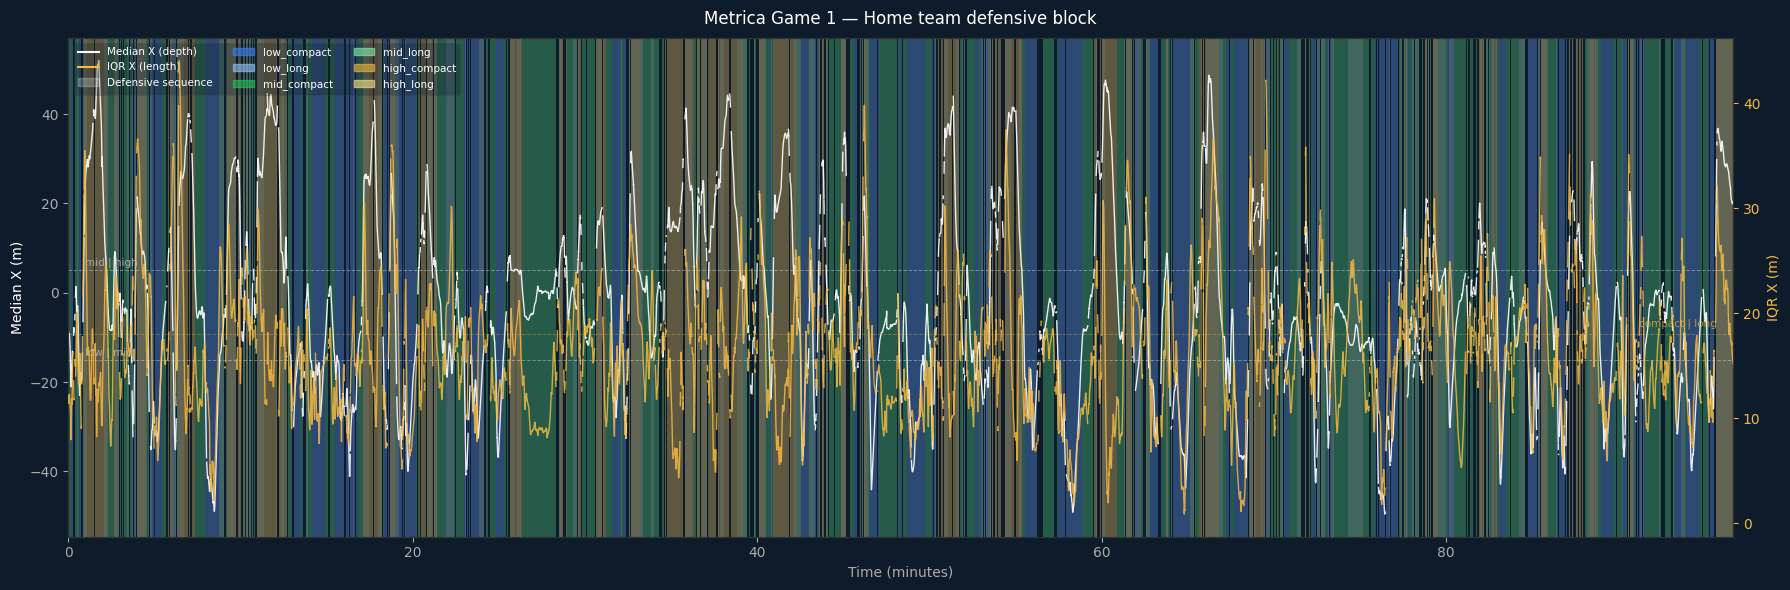

Saved → metrica_timeline.png


In [11]:
fig, ax1, ax2 = plot_match_timeline(
    frame_results=frame_results,
    sequences=sequences,
    fps=25.0,
    x_axis='minutes',
    title='Metrica Game 1 — Home team defensive block',
    save_path='metrica_timeline.png',
)
plt.show()
print('Saved → metrica_timeline.png')

## 6. Static frame

Pick the midpoint of the longest defensive sequence and render the pitch state.

(manual frame — no sequence selected)
Frame:    500  (20.0s)
State:    BlockState(height='mid', length='compact', median_x=-8.976659999999999, iqr_x=11.963700000000001)


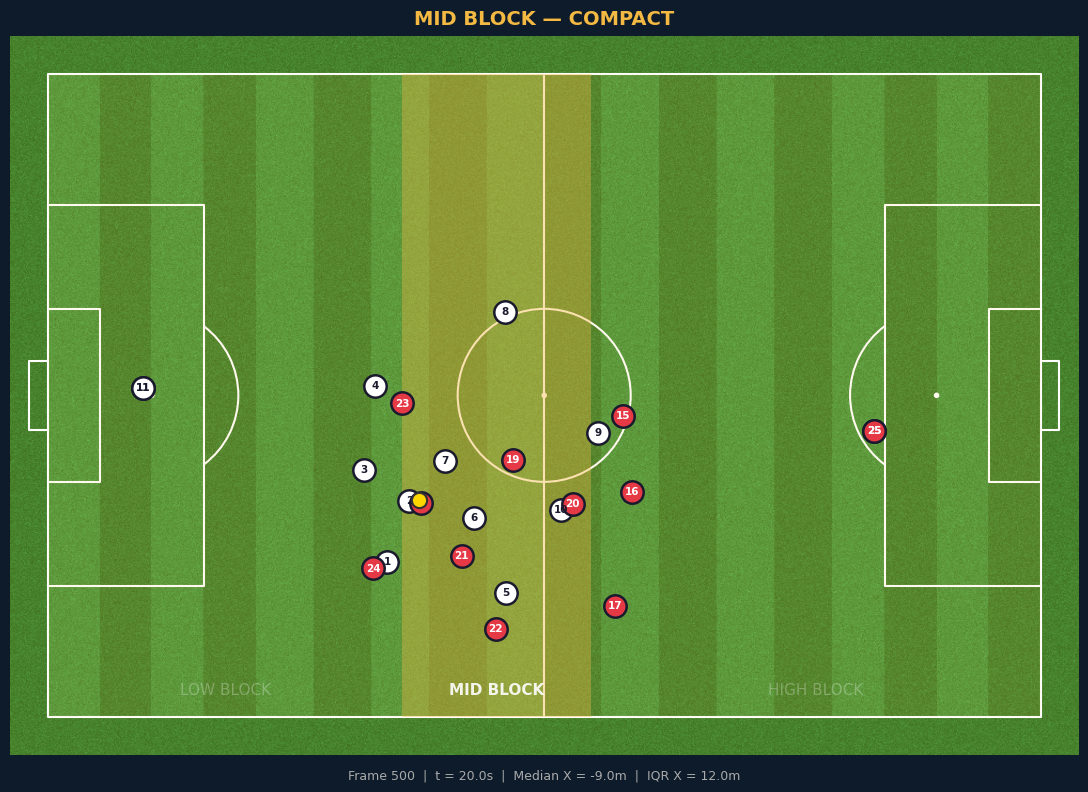

Saved → metrica_frame.png


In [13]:
# ── Frame selector ───────────────────────────────────────────────────────────
# Set FRAME to any integer to inspect that specific frame.
# Leave as None to auto-select the midpoint of the longest defensive sequence.
FRAME = None

# Direction-normalize all positions so the home team always defends toward x = −52.5
flip_mask     = get_flip_mask(ti, ANALYZED_TEAM_IDX)
norm_positions = normalize_direction(ti.positions, flip_mask)  # (N_frames, 22, 2)

# Team / GK slot indices for the visualizer
opposing_idx      = 1 - ANALYZED_TEAM_IDX
defending_slots   = np.where(ti.player_team == ANALYZED_TEAM_IDX)[0].tolist()
attacking_slots   = np.where(ti.player_team == opposing_idx)[0].tolist()
goalkeeper_slots  = np.where(ti.player_is_gk)[0].tolist()
team_indices      = {'defending': defending_slots, 'attacking': attacking_slots}

# Jersey number labels (if available)
jersey_numbers = None
if ti.player_jersey is not None:
    jersey_numbers = {i: str(j) for i, j in enumerate(ti.player_jersey)}

# seq is always the longest defensive sequence (used by the animation cell below)
seq = max(sequences, key=lambda s: s.n_frames)

# Resolve frame
n_frames = norm_positions.shape[0]
if FRAME is None:
    frame     = seq.start_frame + seq.n_frames // 2
    seq_label = f'Sequence: {seq.sequence_id}  ({seq.n_frames} frames)'
else:
    frame     = int(FRAME) % n_frames  # wrap if out of range
    seq_label = f'(manual frame — seq still set to longest sequence)'

state = frame_results.block_state_at(frame)

# Ball position (direction-normalized)
ball_xy = None
if ti.ball_positions is not None:
    b = ti.ball_positions[frame].copy()
    if flip_mask[frame]:
        b[0] *= -1.0
    if not np.isnan(b).any():
        ball_xy = b

print(seq_label)
print(f'Frame:    {frame}  ({frame/25:.1f}s)')
print(f'State:    {state}')

fig, ax = plot_frame(
    positions=norm_positions[frame],
    team_indices=team_indices,
    goalkeeper_indices=goalkeeper_slots,
    config=config,
    block_state=state,
    ball_xy=ball_xy,
    frame_id=frame,
    timestamp=frame / 25.0,
    jersey_numbers=jersey_numbers,
    pitch_length=ti.pitch_size[0],
    pitch_width=ti.pitch_size[1],
    save_path='metrica_frame.png',
)
plt.show()
print('Saved → metrica_frame.png')


## 7. Sequence animation

Animate the same sequence. `frame_step=3` reduces the GIF to ~8 fps.

> **Note:** MP4 output requires `ffmpeg` installed (`brew install ffmpeg` / `apt install ffmpeg`).
> To produce a GIF instead, change the extension to `.gif` — no extra dependencies needed.

In [8]:
MAX_FRAMES  = 300   # cap at 300 frames (~12s at 25fps) to keep the file small
FRAME_STEP  = 3
OUTPUT_PATH = 'metrica_sequence.gif'

s = frame
e = min(norm_positions.shape[0], s + MAX_FRAMES)

anim_positions = []
anim_states    = []
anim_balls     = []

for f in range(s, e):
    pos = ti.positions[f].copy()
    if flip_mask[f]:
        pos[:, 0] *= -1.0
    anim_positions.append(pos)
    anim_states.append(frame_results.block_state_at(f))

    if ti.ball_positions is not None:
        b = ti.ball_positions[f].copy()
        if flip_mask[f]:
            b[0] *= -1.0
        anim_balls.append(b if not np.isnan(b).any() else None)
    else:
        anim_balls.append(None)

print(f'Animating {len(anim_positions)} frames (step={FRAME_STEP}) → {OUTPUT_PATH} …')

animate_sequence(
    frames=anim_positions,
    team_indices=team_indices,
    goalkeeper_indices=goalkeeper_slots,
    config=config,
    block_states=anim_states,
    ball_positions=anim_balls,
    fps=25,
    output_path=OUTPUT_PATH,
    frame_step=FRAME_STEP,
    jersey_numbers=jersey_numbers,
    start_frame=s,
    pitch_length=ti.pitch_size[0],
    pitch_width=ti.pitch_size[1],
)

print(f'Done → {OUTPUT_PATH}')


Animating 300 frames (step=3) → metrica_sequence.gif …
Done → metrica_sequence.gif


## 8. Per-sequence breakdown

Quick look at the distribution of dominant states across all sequences.

In [9]:
from collections import Counter

lengths_by_state = {}
for seq in sequences:
    s_states = frame_results.combined_states[seq.start_frame:seq.end_frame]
    valid    = [s for s in s_states if s is not None]
    dominant = Counter(valid).most_common(1)[0][0] if valid else None
    if dominant:
        lengths_by_state.setdefault(dominant, []).append(seq.n_frames)

print(f'{'State':<18} {'N seqs':>7}  {'Median len (frames)':>20}  {'Total frames':>14}')
print('-' * 65)
for state, lens in sorted(lengths_by_state.items(), key=lambda x: -len(x[1])):
    print(f'{state:<18} {len(lens):>7}  {int(np.median(lens)):>20}  {sum(lens):>14}')

State               N seqs   Median len (frames)    Total frames
-----------------------------------------------------------------
mid_compact            186                    42           37171
low_compact            131                    66           35054
high_compact           120                    31           15714
high_long              112                    63           22678
mid_long               105                    41            9335
low_long                44                    38            2796
